<a href="https://colab.research.google.com/github/ep42south-star/EMSC2010_Oceans_Eleven_Variables_Group_Project_5/blob/main/Ocean's_Eleven_Variables_Group_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 5

## 1. Project Overview
Group name: Ocean's Eleven Variables

Project week: Week 10

Project title: Time Series Analysis of Arctic Sea Ice Extent Under Climate Change

Datasets used (name and source):

Name of dataset used: Monthly Sea Ice Extend Data - National Snow and Ice Data Center (NSIDC)

Link to dataset (before it was cleaned):

https://1drv.ms/x/c/9c4c142238c6bf2b/IQA1ATL7r4BjRKdMoW6D1jVQAdEviIa27fp0QfEJ0ZSvs8Q?e=ZnRJ9j

Link to dataset (after it was cleaned):

https://1drv.ms/x/c/9c4c142238c6bf2b/IQDcyM2XJWoVT6rF2gkcIcGnAc4YPPVX7kpW_ZPx45ggDDY?e=1RTqWr

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Emily | Charlotte | Yes| Add note|
| Data steward | Jiah | Georgie | Yes| Add note|
| Analysis / modelling | Mel | Leo | Yes| Add note|
| Visualisation / interpretation | Leo | Mel | Yes| Add note|
| Narrative | Georgie | Jiah | Yes| Add note|
| Quality Control / Reproducibility  | Charlotte | Emily | Yes| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Aim:**

Our aim for this project is to use time series analysis to investigate long-term changes in Arctic sea ice extent and determine whether observable trends can be used to forecast future sea ice decline. Arctic sea ice is a key indicator of climate change, as reductions in ice extent influence global albedo, ocean circulation, and broader climate feedback mechanisms. By analysing historical monthly sea ice extent data, we aim to identify long-term trends, seasonal variability, and potential future changes in Arctic ice coverage.

Notes about how the dataset was cleaned:


1.   Correcting incorrectly labelled column headers for clarity and consistency

2.   Removing duplicate entries


1.   Checking for and removing any invalid or missing values

2.   Validating month values to ensure they ranged from 1 to 12


1.   Converting all variables into appropriate numeric formats
2.   Creating a proper datetime column from the year and month values

1.  Sorting the dataset chronologically for accurate time series analysis









**Introduction:**

Arctic sea ice is a key indicator of climate change, as declining ice extent reflects rising global temperatures and changing Earth system processes. Reductions in sea ice also decrease Earth's albedo, increasing heat absorption and further accelerating warming, meaning less solar radiation is reflected back into space and more is absorbed by the ocean, amplifying warming through positive climate feedback mechanisms. Given its importance in regulating global climate systems, Arctic sea ice provides a valuable dataset for examining long-term environmental change through time series analysis.

In [3]:
#Mel Analysis

#IMPORTING THE LIBRARIES
import pandas as pd #for data importing
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

We imported all the required libraries necessary for our modelling and read in the dataset.

In [4]:
#IMPORTING THE SPREADSHEET DATASET

spreadsheet_name = 'arctic_sea_ice_clean_plain.xlsx'
worksheet_name = 'Data'
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [5]:
df.head()

,date,year,month,sea_ice_extent
0,1980-01-01,1980,1,14.862
1,1980-02-01,1980,2,15.955
2,1980-03-01,1980,3,16.041
3,1980-04-01,1980,4,15.429
4,1980-05-01,1980,5,13.793


We converted the year and month variables into decimal years, creating a new age variable.

We then converted the age and sea ice extent data to numpy arrays.

In [6]:
#CONVERT TO NUMPY ARRAY
age = df['year'] + (df['month'] - 1)/12 #convert to decimal years
age = age.values.astype(float) #convert to numpy array

sie = df['sea_ice_extent'].values.astype(float) #convert to numpy array

We defined functions for calculating the frequency spectrum, and creating highpass, lowpass, and bandpass filters.

In [7]:
#DEFINE FUNCTIONS FOR FREQUENCY CLEANING

def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

We plotted the data and then calculated and plotted the frequency spectrum.

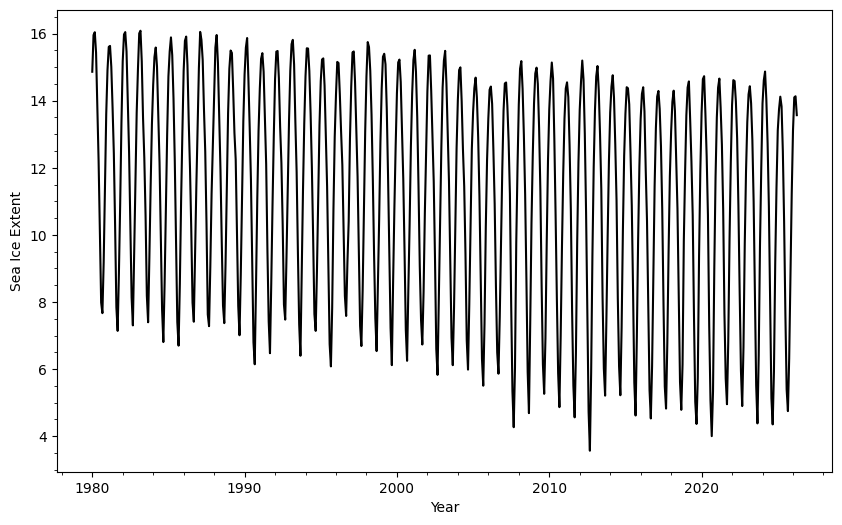

In [8]:
#DATA PLOT
plt.figure(figsize=(10,6))
plt.plot(age,sie,'k') #plot the sea ice data
plt.xlabel('Year') #label the x-axis
plt.ylabel('Sea Ice Extent') #label the y-axis
plt.xlim
plt.minorticks_on() #add minorticks

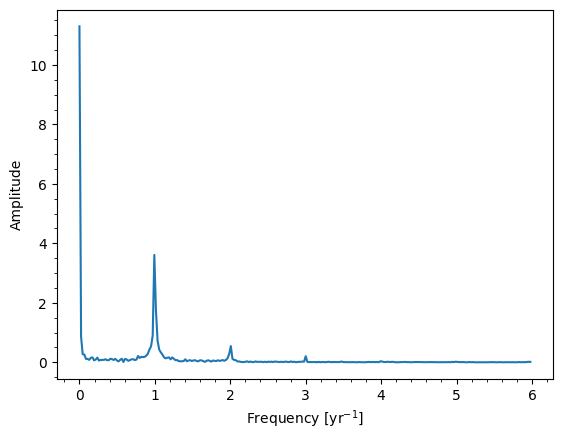

In [9]:
#PLOT FREQUENCY SPECTRUM
freqs, amps = freq_spectrum(age,sie) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [yr$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.minorticks_on() #add minorticks

We fit a first-order polynomial to the data.

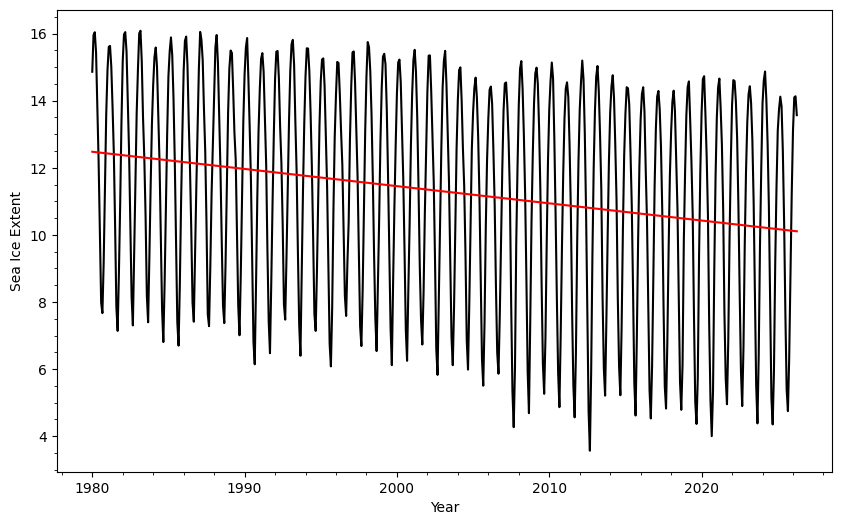

In [10]:
#Leo's Code
plt.figure(figsize=(10,6))
pp = np.polyfit(age,sie,1) #fit a trendline to the data
plt.plot(age,sie,'k') #plot the original data
plt.plot(age,np.polyval(pp,age),'r') #plot the trendline
plt.xlabel('Year') #label the x-axis
plt.ylabel('Sea Ice Extent') #label the y-axis
plt.minorticks_on() #add minorticks

We detrend the data using a polynomial to remove the effect of the long-term trend. The detrended data is the original data minus the fitted line.

We calculate and plot the frequency spectrum for this detrended data, and plot vertical lines at the frequencies corresponding to signals.

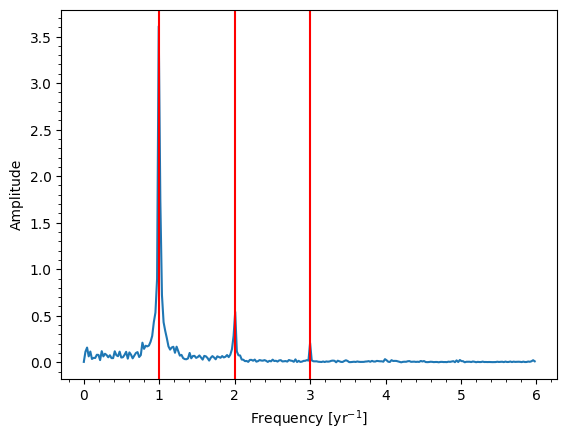

In [11]:
detrend = sie-np.polyval(pp,age) #calculate the detrended data
freqs, amps = freq_spectrum(age,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [yr$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.minorticks_on() #add minorticks

#Peaks in frequency
plt.gca().axvline(x=1,color='r')
plt.gca().axvline(x=2,color='r')
plt.gca().axvline(x=3,color='r')

These three signals in the frequency spectrum represent different components that contribute to trends in sea ice extent. It appears there are annual, biannual and triannual cycles  contriibuting to the overall trend. We will filter to isolate each of these signals.

The data is filtered to isolate each of the 3 signals (annual, biannual & triannual), and the filtered signal plotted over the detrended data.

To isolate the annual signal, we use a lowpass filter with a cutoff of 1.2\.

Text(0.5, 1.0, 'Annual cycle')

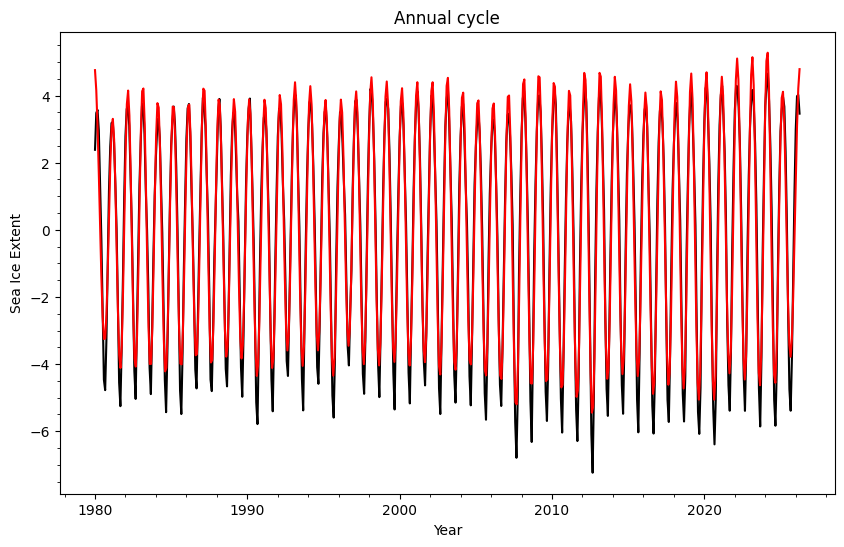

In [12]:
plt.figure(figsize=(10,6))
plt.plot(age,detrend,'k') #plot the detrended data
x, y = lowpass_filter(age,detrend, 1.2) #obtain the filtered signal with a cutoff of 1 cycles/year
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'Sea Ice Extent') #label the y-axis
plt.minorticks_on() #add minorticks
plt.title('Annual cycle')

The annual cycle matches the sea ice extent trend almost exactly, though is shifted up very slightly. This indicates that this annual cycle is primarily responsible for the pattern in varying sea ice extent. This cycle is attributed to seasonal freezing and melting.

To isolate the biannual signal, we use a bandpass filter with a range of 1.8 to 2.2.

Text(0.5, 1.0, 'Biannual cycle')

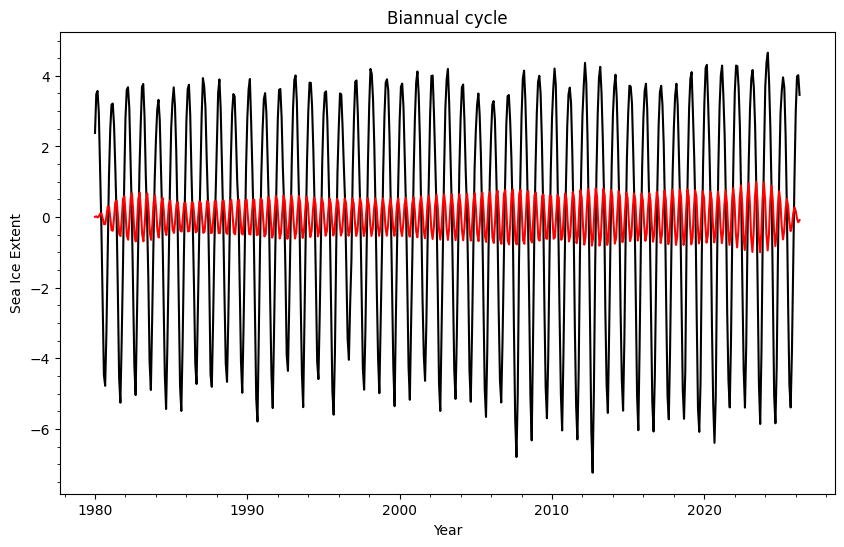

In [13]:
plt.figure(figsize=(10,6))
plt.plot(age,detrend,'k') #plot the detrended data
x, y = bandpass_filter(age,detrend, [1.8, 2.2]) #obtain the filtered signal with a cutoff of 2 cycles/year
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'Sea Ice Extent') #label the y-axis
plt.minorticks_on() #add minorticks
plt.title('Biannual cycle')

The biannual cycle also demonstrates a clear trend and helps us explain why the annual cycle is shifted up from the data. Troughs in cycle 2 align with the peaks and troughs in sea ice extent (and similarly with the peaks & troughs in cycle 1). Therefore the minimums in cycle 2 play the role of reducing the maximums in sea ice extent, so it doesn't reach as high numbers as it would if solely influenced by cycle 1. This biannual cycle may be attributed to winds over the Arctic.

To isolate the triannual signal, we use a highpass filter with a cutoff of 2.8.

Text(0.5, 1.0, 'Triannual cycle')

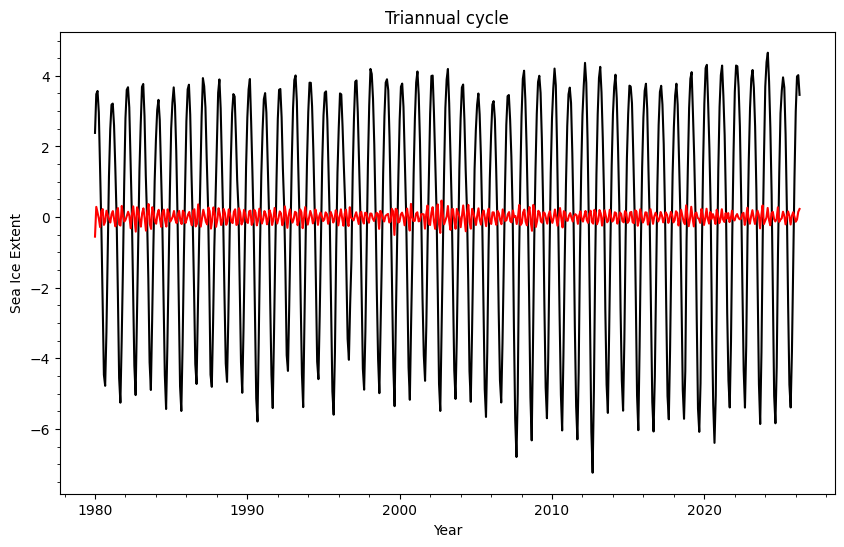

In [14]:
plt.figure(figsize=(10,6))
plt.plot(age,detrend,'k') #plot the detrended data
x, y = highpass_filter(age,detrend, 2.8) #obtain the filtered signal with a cutoff of 3 cycles/year
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'Sea Ice Extent') #label the y-axis
plt.minorticks_on() #add minorticks
plt.title('Triannual cycle')

The triannual cycle, while consistent in its trend, is deemed to have a minimal effect on the overall trend for sea ice extent due to its small amplitude compared to the annual and biannual cycles. Scientific literature does not seem to support the existence of a triannual cycle driving Arctic sea ice extent, and I was unable to find any sources suggesting what this cycle may be attributed to.  



**Conclusions**

Isolating and understanding the effects and interactions of these cycles on sea ice extent enables us to predict how sea ice extent may vary in future depending on changes to each of these individual cycles.

The dominant cycle influencing Arctic sea ice extent is the annual cycle of melting and freezing due to seasonal variability. This cycle interacts with the more minor biannual and triannual cycles which negate it somewhat, causing an overall decrease in sea ice extent. Climate change is causing stronger near-surface winds at the Arctic, but decreasing the strength of the polar jet stream. This will have the effect of intensifying the minimums in cycle 2, which will both reduce the maximum sea ice extent in winters, as well as reducing the summer sea ice extent even further.

A limitation of this project is that we were unable to elucidate longer term trends influencing sea ice extent. There are multi-year cycles that weren’t able to be analysed as they didn’t show strong enough of a signal in the frequency spectrum to be able to confidently isolate. If we could incorporate longer term large-scale atmospheric patterns like the Quasi-Biennial Oscillation and the Arctic Oscillation, this would have been very beneficial to future predictions.

# **Week 10 Group Project Reflections:**



**Jiah:** As the Data Steward Lead, my role involved preparing the raw Arctic sea ice dataset for analysis by ensuring it was accurate, structured, and suitable for time series modelling. This included identifying inconsistencies in the raw data, cleaning and organising the dataset, and creating a chronological format that could be directly used for coding and visualisation. This role was important in establishing a reliable foundation for the group’s analysis and ensuring the dataset was scientifically usable.

**Mel:** As the analysis model lead, my role was to implement the main analysis model and explain the process in clear and understandle terms. I uploaded the cleaned dataset into the code, and coverted the dataset into numpy arrays. I also also implemented the filtering analysis for the sea ice extent data, and graphed the model for the frequency spectrum. This role was important in helping to extract the dataset into meaningful information, and taught me the value of data analysis in the removal of guesswork.

**Leo:** For the Wk10 group project I was the Visualisation / interpretation primary. My role included generating the peaks in frequency graph as well as detrending the data and plotting it with the cutoff range of 1 - 3 cycles per year as shown in the frequency graph. My main challenges were figuring out how far the cutoff was, needing to go back and correct my part of code later in the project due to misunderstanding. I started to under fit the trendline to the data and struggled with the graphing code before going back to the lecture material. This role was importand in visualising how much interference is in the collected data and thus ind

**Georgie:** My role this week was narrative lead, I explained what each bit of code was doing and justified coding decisions made. I added titles to figures and clarified some axes labels. I also suggested some changes to be made to the code to better fit the narrative, and enable me to justify the decisions. I explained the conclusions from our analysis and the relevance of this coding project to our aims, as well as real world applications of our analysis. I also discussed some of the limitations of our analysis in this project.


**Charlotte:** My role this week was Quality Control, in which my main responsibilities included making sure the chosen data set can be intergreted into the colab and making sure the code runs smoothly, without any issues. I made sure to look over the code, especially the text parts in order to make sure there were no spelling or punctuation errors.

**Emily:** I was the GitHub Repository and Integration Lead for this project. The only challenge I encountered was making sure everyone had permission to edit the Colab notebook, which caused a slight hiccup at the beginning. Apart from this, I made sure the notebook and repository were organised correctly.